# DECOMP — Exploratory Data Analysis

Visual tour of the IBL Brain-Wide Map data we're using, the per-session population activity, and the behavior covariates that feed into the GLM / SVCA / CCA / pCCA pipeline.

**Loads from `data/cache/` whenever possible** — re-downloading is needed only for trials and pose, which are pulled lazily.

Sections:
1. Dataset overview — session counts, region coverage, unit-count distributions
2. Behavior covariates — wheel, motion energy, pupil, licks (over time + distributions + correlations)
3. Neural population activity — firing rate distributions, PCA, heatmaps per region
4. Trial structure — task design, contrast, choice, response-time
5. Trial-averaged neural responses — PSTHs around stim onset and first movement
6. Behavior ↔ neural relationships — pop activity vs running speed / pupil
7. Cross-region preview — V1 vs CB leading PC time series (the input to CCA)

Run all top-to-bottom. Most cells finish in seconds; the trials/pose cell takes ~30 s on first call and is cached after.

In [1]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Apply the same style we use in figures.py for consistency
from decomp.viz.figures import _BASE_STYLE, _REGION_COLORS
mpl.rcParams.update(_BASE_STYLE)

CACHE = Path('../data/cache')
OUT = Path('../outputs')
summary = json.loads((OUT / 'summary.json').read_text())

print('Strategy:', summary['strategy'])
print('Pair eids (V1+CB):', summary['pair_eids'])
print(f"Pool eids per ROI: {{r: len(eids) for r, eids in summary['pool_eids'].items()}}")
print(f"Total unique sessions: {len(summary['union_eids'])}")

Strategy: V1+CB pair: 3 sessions at min_units=5 | per-region pool: VISp=10, CB=10, MO=10, CA1=10 sessions at min_units=10
Pair eids (V1+CB): ['41431f53-69fd-4e3b-80ce-ea62e03bf9c7', '09b2c4d1-058d-4c84-9fd4-97530f85baf6', 'a7763417-e0d6-4f2a-aa55-e382fd9b5fb8']
Pool eids per ROI: {r: len(eids) for r, eids in summary['pool_eids'].items()}
Total unique sessions: 41


## 1. Dataset overview

How many sessions cover which regions, and how many good-QC units does each session contribute?

In [2]:
# Build a per-session per-region unit-count table from the cached spike matrices
import re
rows = []
for path in sorted(CACHE.glob('*_spikes_*.npy')):
    m = re.match(r'^(?P<eid>[a-f0-9-]+)_spikes_(?P<roi>[A-Za-z0-9]+)\.npy$', path.name)
    if not m:
        continue
    arr = np.load(path, mmap_mode='r')
    rows.append({'eid': m['eid'], 'roi': m['roi'], 'n_units': arr.shape[0], 'T_bins': arr.shape[1]})
units_df = pd.DataFrame(rows)
print(f'Sessions × regions covered in cache: {len(units_df)} entries')
units_df.groupby('roi').agg(
    n_sessions=('eid', 'nunique'),
    median_units=('n_units', 'median'),
    min_units=('n_units', 'min'),
    max_units=('n_units', 'max'),
    total_units=('n_units', 'sum'),
).round(1)

Sessions × regions covered in cache: 51 entries


,n_sessions,median_units,min_units,max_units,total_units
roi,,,,,
CA1,11,39.0,20,131,612
CB,15,195.0,4,287,2222
MO,11,86.0,54,226,1119
VISp,14,40.0,4,63,495


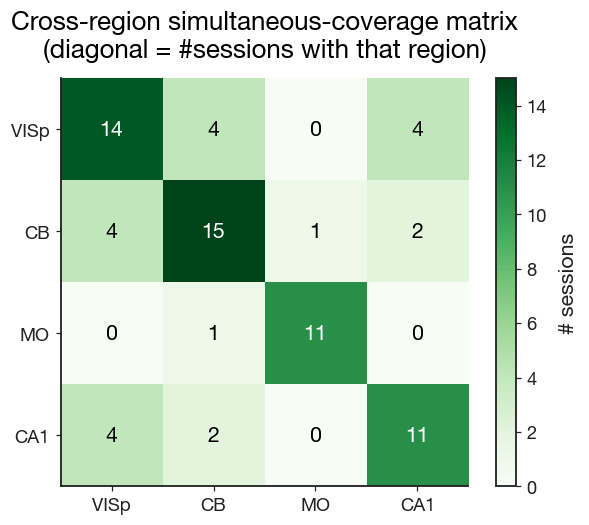

In [3]:
# Cross-region coverage matrix: how many sessions have BOTH region A AND region B?
rois = ['VISp', 'CB', 'MO', 'CA1']
cov = pd.DataFrame(0, index=rois, columns=rois)
for eid, grp in units_df.groupby('eid'):
    present = set(grp['roi'].tolist())
    for a in rois:
        for b in rois:
            if a in present and b in present:
                cov.loc[a, b] += 1
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cov.values, cmap='Greens', vmin=0)
for i in range(len(rois)):
    for j in range(len(rois)):
        ax.text(j, i, int(cov.values[i, j]), ha='center', va='center',
                color='white' if cov.values[i, j] > cov.values.max() / 2 else 'black',
                fontsize=14)
ax.set_xticks(range(len(rois))); ax.set_xticklabels(rois)
ax.set_yticks(range(len(rois))); ax.set_yticklabels(rois)
ax.set_title('Cross-region simultaneous-coverage matrix\n(diagonal = #sessions with that region)')
plt.colorbar(im, ax=ax, fraction=0.046, label='# sessions')
plt.tight_layout(); plt.show()

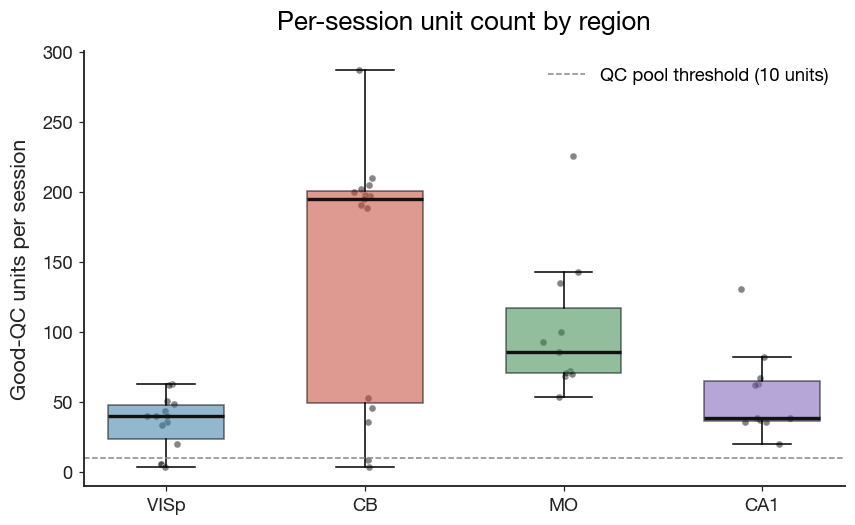

In [4]:
# Distribution of unit counts per region across sessions
fig, ax = plt.subplots(figsize=(8, 5))
positions = np.arange(len(rois)) * 1.2
data = [units_df.loc[units_df['roi'] == r, 'n_units'].to_numpy() for r in rois]
bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True, showfliers=False,
                medianprops=dict(color='#111', linewidth=2.2))
for patch, r in zip(bp['boxes'], rois):
    patch.set_facecolor(_REGION_COLORS.get(r, '0.6')); patch.set_alpha(0.55)
for j, (r, vals) in enumerate(zip(rois, data)):
    rng = np.random.default_rng(j)
    ax.scatter(np.full(len(vals), positions[j]) + rng.normal(0, 0.05, len(vals)),
               vals, s=22, color='#222', alpha=0.55, edgecolors='white', linewidths=0.6)
ax.set_xticks(positions); ax.set_xticklabels(rois)
ax.set_ylabel('Good-QC units per session')
ax.set_title('Per-session unit count by region')
ax.axhline(10, ls='--', color='#888', lw=1, label='QC pool threshold (10 units)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

## 2. Focal session — behavior covariates

We deep-dive on the strongest V1+CB pair session: `41431f53` (CSH_ZAD_022, 63 V1 + 46 CB units). Same session that drives fig02 / fig03 / fig04.

In [5]:
FOCAL_EID = '41431f53-69fd-4e3b-80ce-ea62e03bf9c7'
covariates = pd.read_parquet(CACHE / f'{FOCAL_EID}_covariates.parquet')
bin_centers = np.load(CACHE / f'{FOCAL_EID}_bin_centers.npy')
covariates.index = bin_centers
print(f'Bin grid: T = {len(bin_centers):,} bins at {(bin_centers[1] - bin_centers[0]) * 1000:.0f} ms')
print(f'Session window: {bin_centers[0]:.1f} s to {bin_centers[-1]:.1f} s '
      f'({(bin_centers[-1] - bin_centers[0]) / 60:.1f} min)')
print('Covariates available:', list(covariates.columns))
covariates.describe().round(3)

Bin grid: T = 262,779 bins at 20 ms
Session window: 6.3 s to 5261.9 s (87.6 min)
Covariates available: ['wheel_velocity', 'wheel_acceleration', 'me_whisker', 'pupil', 'lick_rate']


,wheel_velocity,wheel_acceleration,me_whisker,pupil,lick_rate
count,262779.000,262779.000,262779.000,262779.000,262779.000
mean,0.119,-0.000,2.826,16.443,1.595
std,0.779,8.414,1.988,2.028,9.339
min,-9.187,-173.121,0.303,9.962,0.000
25%,-0.001,-0.014,1.676,15.076,0.000
50%,0.000,0.000,1.900,16.289,0.000
75%,0.010,0.004,3.537,17.789,0.000
max,10.293,210.467,37.729,28.430,100.000


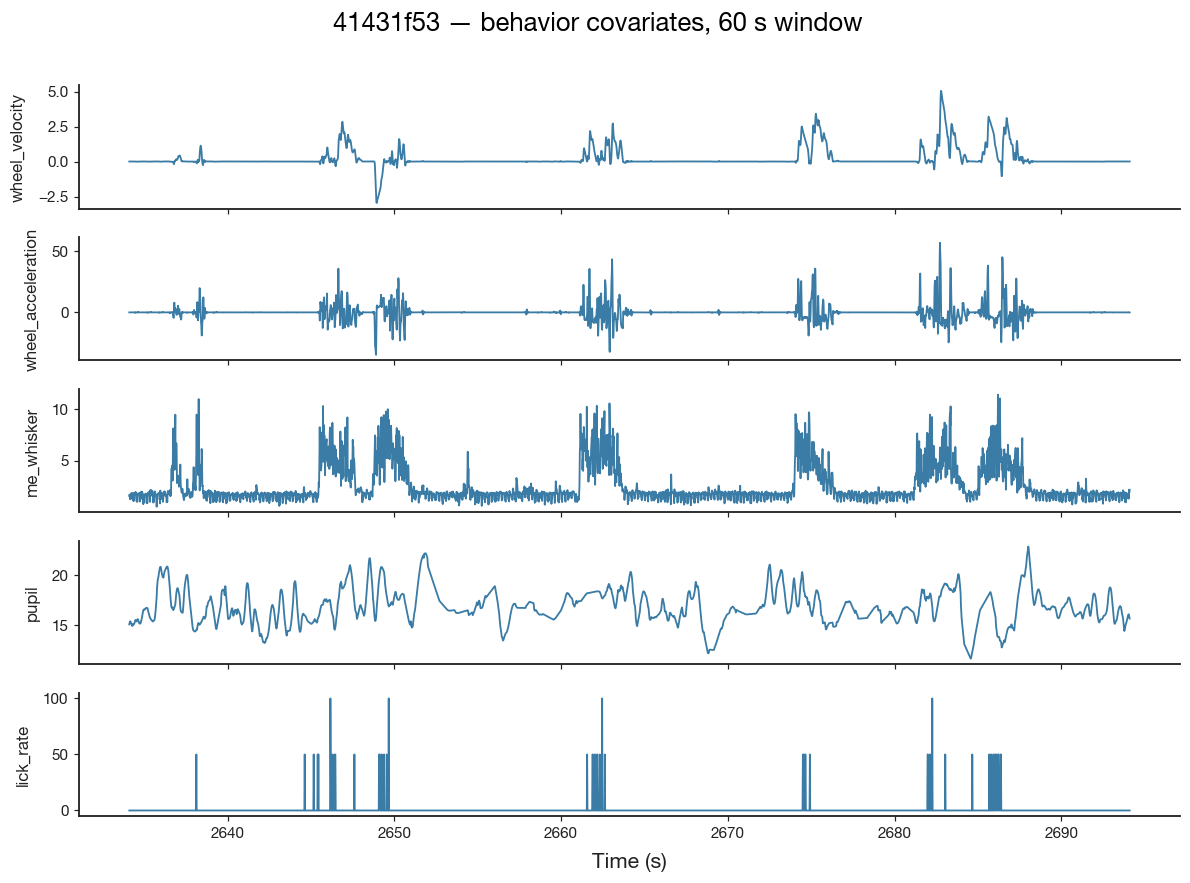

In [6]:
# Behavior over time (zoom on a 60 s window in the middle of the session)
t0 = bin_centers[len(bin_centers) // 2]
t1 = t0 + 60.0
mask = (bin_centers >= t0) & (bin_centers <= t1)
fig, axes = plt.subplots(len(covariates.columns), 1, figsize=(11, 1.6 * len(covariates.columns)),
                          sharex=True)
for ax, col in zip(axes, covariates.columns):
    ax.plot(bin_centers[mask], covariates[col].to_numpy()[mask], color='#3a7ca5', lw=1.2)
    ax.set_ylabel(col, fontsize=11)
    ax.tick_params(labelsize=10)
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'{FOCAL_EID[:8]} — behavior covariates, 60 s window', y=1.005)
plt.tight_layout(); plt.show()

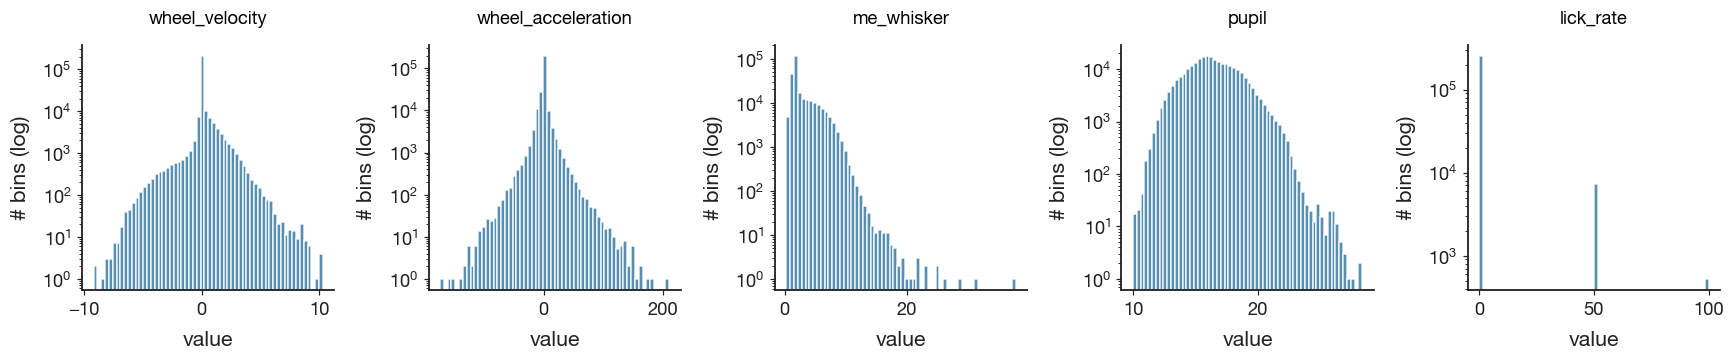

In [7]:
# Distributions of each covariate
ncols = len(covariates.columns)
fig, axes = plt.subplots(1, ncols, figsize=(3.2 * ncols, 3.5))
for ax, col in zip(axes, covariates.columns):
    vals = covariates[col].dropna().to_numpy()
    ax.hist(vals, bins=60, color='#3a7ca5', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('value'); ax.set_yscale('log'); ax.set_ylabel('# bins (log)')
plt.tight_layout(); plt.show()

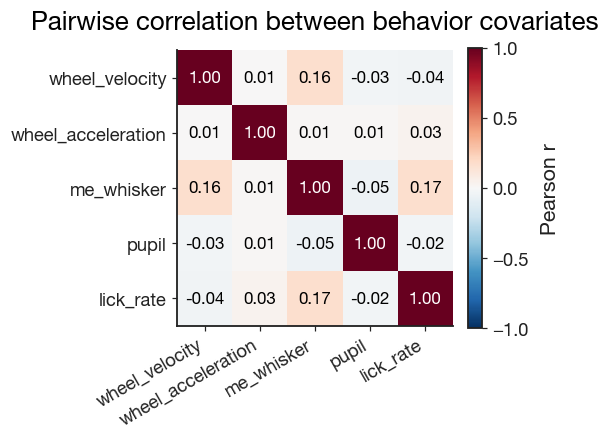

In [8]:
# Pairwise correlation between covariates
# Subsample to 50,000 bins to keep numpy.corrcoef fast
sub = covariates.iloc[::max(1, len(covariates) // 50000)]
corr = sub.corr()
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                fontsize=11, color='black' if abs(corr.values[i, j]) < 0.6 else 'white')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=30, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
ax.set_title('Pairwise correlation between behavior covariates')
plt.colorbar(im, ax=ax, fraction=0.046, label='Pearson r')
plt.tight_layout(); plt.show()

## 3. Neural data — per-region population activity

In [9]:
# Load spike-count matrices for the focal session
spikes = {}
for path in sorted(CACHE.glob(f'{FOCAL_EID}_spikes_*.npy')):
    m = re.match(r'^.*_spikes_(?P<roi>[A-Za-z0-9]+)\.npy$', path.name)
    if m:
        spikes[m['roi']] = np.load(path)
for roi, mat in spikes.items():
    bin_s = (bin_centers[1] - bin_centers[0])
    print(f'{roi:5s}: shape={mat.shape}, mean firing rate = {mat.mean() / bin_s:.2f} Hz')

CB   : shape=(46, 262779), mean firing rate = 8.19 Hz
VISp : shape=(63, 262779), mean firing rate = 4.47 Hz


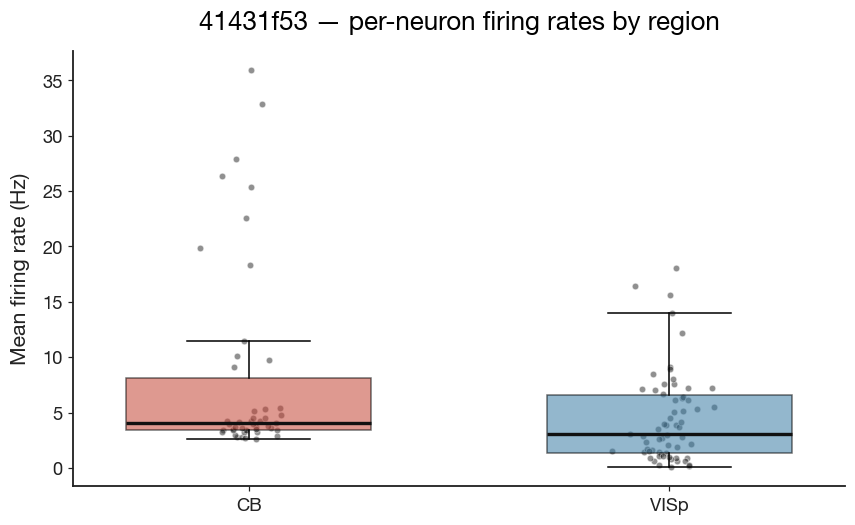

In [10]:
# Mean firing rate distribution per region (one dot per neuron)
bin_s = bin_centers[1] - bin_centers[0]
fig, ax = plt.subplots(figsize=(8, 5))
positions = np.arange(len(spikes)) * 1.2
rates = [(mat.mean(axis=1) / bin_s) for mat in spikes.values()]
labels = list(spikes.keys())
bp = ax.boxplot(rates, positions=positions, widths=0.7, patch_artist=True, showfliers=False,
                medianprops=dict(color='#111', linewidth=2.2))
for patch, r in zip(bp['boxes'], labels):
    patch.set_facecolor(_REGION_COLORS.get(r, '0.6')); patch.set_alpha(0.55)
for j, (r, vals) in enumerate(zip(labels, rates)):
    rng = np.random.default_rng(j)
    ax.scatter(np.full(len(vals), positions[j]) + rng.normal(0, 0.06, len(vals)),
               vals, s=18, color='#222', alpha=0.5, edgecolors='white', linewidths=0.6)
ax.set_xticks(positions); ax.set_xticklabels(labels)
ax.set_ylabel('Mean firing rate (Hz)')
ax.set_title(f'{FOCAL_EID[:8]} — per-neuron firing rates by region')
plt.tight_layout(); plt.show()

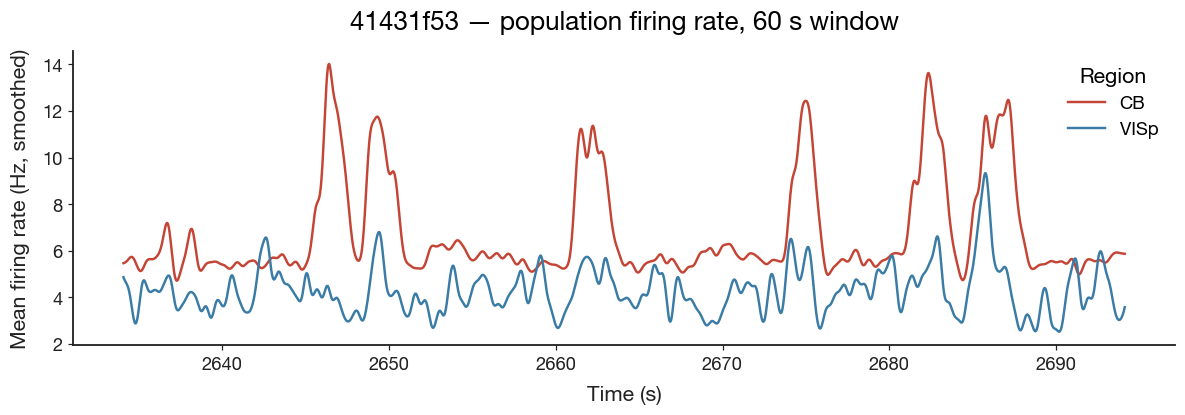

In [11]:
# Population firing rate over time, per region (Gaussian-smoothed)
from scipy.ndimage import gaussian_filter1d
smoothed = {}
for roi, mat in spikes.items():
    pop_rate = (mat.mean(axis=0) / bin_s)  # average across neurons -> (T,)
    smoothed[roi] = gaussian_filter1d(pop_rate, sigma=10)  # ~200 ms smooth at 20 ms bins

# Plot a 60 s window
fig, ax = plt.subplots(figsize=(11, 4))
for roi, sig in smoothed.items():
    ax.plot(bin_centers[mask], sig[mask], label=roi,
            color=_REGION_COLORS.get(roi, '#444'), lw=1.6)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Mean firing rate (Hz, smoothed)')
ax.set_title(f'{FOCAL_EID[:8]} — population firing rate, 60 s window')
ax.legend(loc='upper right', title='Region')
plt.tight_layout(); plt.show()

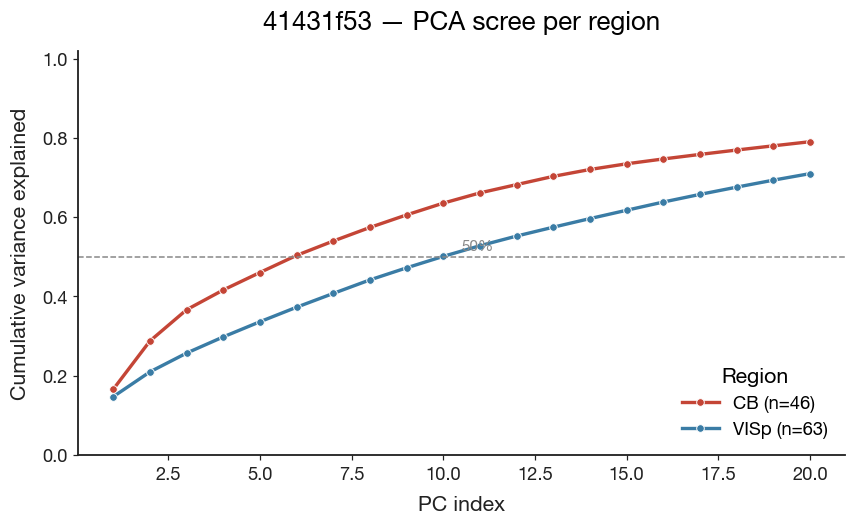

In [12]:
# Per-region PCA scree: how much variance does each component explain?
from numpy.linalg import svd
fig, ax = plt.subplots(figsize=(8, 5))
for roi, mat in spikes.items():
    Xc = mat.astype(float) - mat.mean(axis=1, keepdims=True)
    s = svd(Xc, full_matrices=False, compute_uv=False)
    var_explained = (s ** 2) / (s ** 2).sum()
    cum = np.cumsum(var_explained)
    n_show = min(20, len(cum))
    ax.plot(np.arange(1, n_show + 1), cum[:n_show], marker='o', ms=5, mec='white', mew=0.6,
            label=f'{roi} (n={mat.shape[0]})', color=_REGION_COLORS.get(roi, '#444'), lw=2.2)
ax.axhline(0.5, ls='--', color='#888', lw=1)
ax.text(0.5, 0.51, '50%', color='#888', fontsize=10, ha='left', va='bottom',
        transform=ax.get_yaxis_transform())
ax.set_xlabel('PC index'); ax.set_ylabel('Cumulative variance explained')
ax.set_title(f'{FOCAL_EID[:8]} — PCA scree per region')
ax.legend(loc='lower right', title='Region')
ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

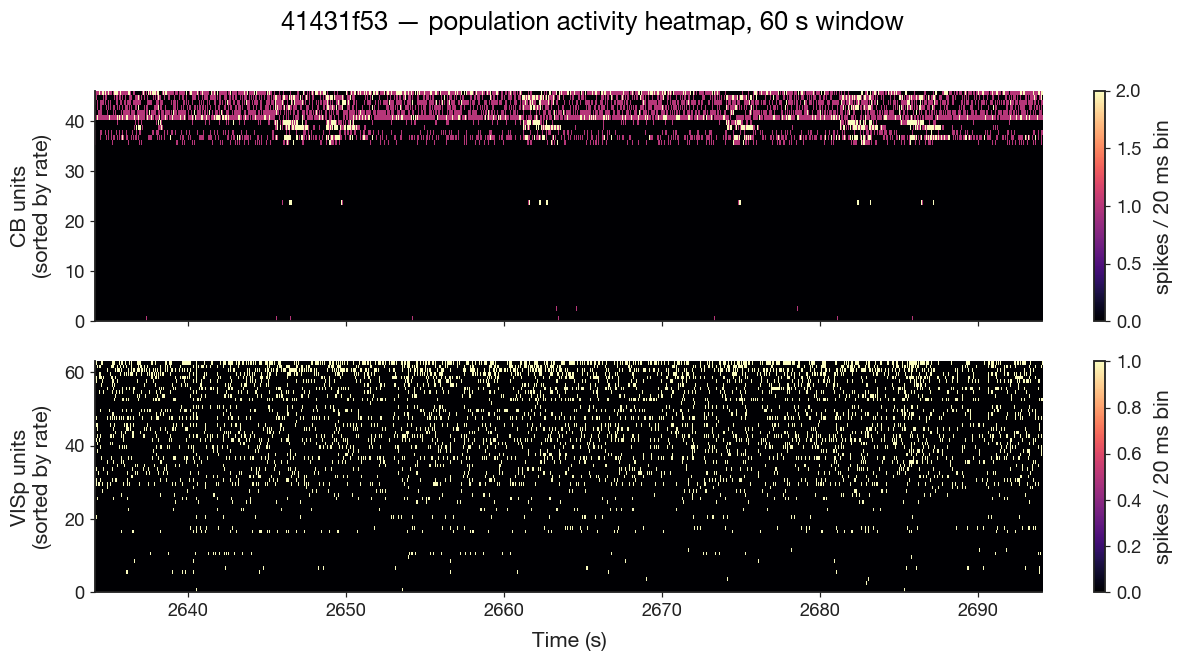

In [13]:
# Heatmap of binned activity for both regions, 60 s window, sorted by mean rate
fig, axes = plt.subplots(len(spikes), 1, figsize=(11, 3 * len(spikes)), sharex=True)
if len(spikes) == 1:
    axes = [axes]
for ax, (roi, mat) in zip(axes, spikes.items()):
    sub_mat = mat[:, mask]
    order = np.argsort(-mat.mean(axis=1))  # high firing rate first
    sub_mat = sub_mat[order]
    im = ax.imshow(sub_mat, aspect='auto', cmap='magma', interpolation='nearest',
                   extent=[bin_centers[mask][0], bin_centers[mask][-1], 0, sub_mat.shape[0]],
                   vmin=0, vmax=np.percentile(sub_mat, 99))
    ax.set_ylabel(f'{roi} units\n(sorted by rate)')
    plt.colorbar(im, ax=ax, fraction=0.025, label='spikes / 20 ms bin')
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'{FOCAL_EID[:8]} — population activity heatmap, 60 s window', y=1.005)
plt.tight_layout(); plt.show()

## 4. Trial structure

Pull the trials table for the focal session via ONE (cached after first call).

In [14]:
from one.api import ONE
from brainbox.io.one import SessionLoader
one = ONE(base_url='https://openalyx.internationalbrainlab.org', password='international', silent=True)
sl = SessionLoader(one=one, eid=FOCAL_EID)
sl.load_trials()
trials = sl.trials
print(f'Trials: {len(trials)}')
trials.head()

Trials: 570


/Users/kevinb/miniforge3/envs/decomp/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


,goCueTrigger_times,intervals_bpod_0,intervals_bpod_1,quiescencePeriod,stimOffTrigger_times,stimOff_times,stimOnTrigger_times,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,probabilityLeft,feedback_times,feedbackType,rewardVolume,firstMovement_times,intervals_0,intervals_1
0,189.365033,0.000000,3.299502,0.541949,190.697132,190.764922,189.298233,189.366261,189.697033,-1.0,189.364828,NaN,1.000,0.5,189.697128,1.0,1.5,189.440376,187.965435,191.264933
1,194.078437,3.708000,7.896203,0.457997,195.294840,195.361629,194.009737,194.079190,194.294738,1.0,194.078290,0.25,NaN,0.5,194.294835,1.0,1.5,194.008376,191.673431,195.861645
2,197.881548,8.255700,11.765703,0.426862,199.169052,199.231108,197.824748,197.882476,198.168949,-1.0,197.881343,NaN,0.250,0.5,198.169048,1.0,1.5,197.929376,196.221143,199.731156
3,201.744861,12.125601,15.649402,0.423191,203.044265,203.114786,201.678161,201.745757,202.044162,-1.0,201.744724,NaN,0.125,0.5,202.044260,1.0,1.5,201.902376,200.091056,203.614868
4,205.594872,16.007200,19.532102,0.501897,206.929076,206.997465,205.531372,205.595705,205.928973,-1.0,205.594772,NaN,0.250,0.5,205.929072,1.0,1.5,205.597376,203.972667,207.497579


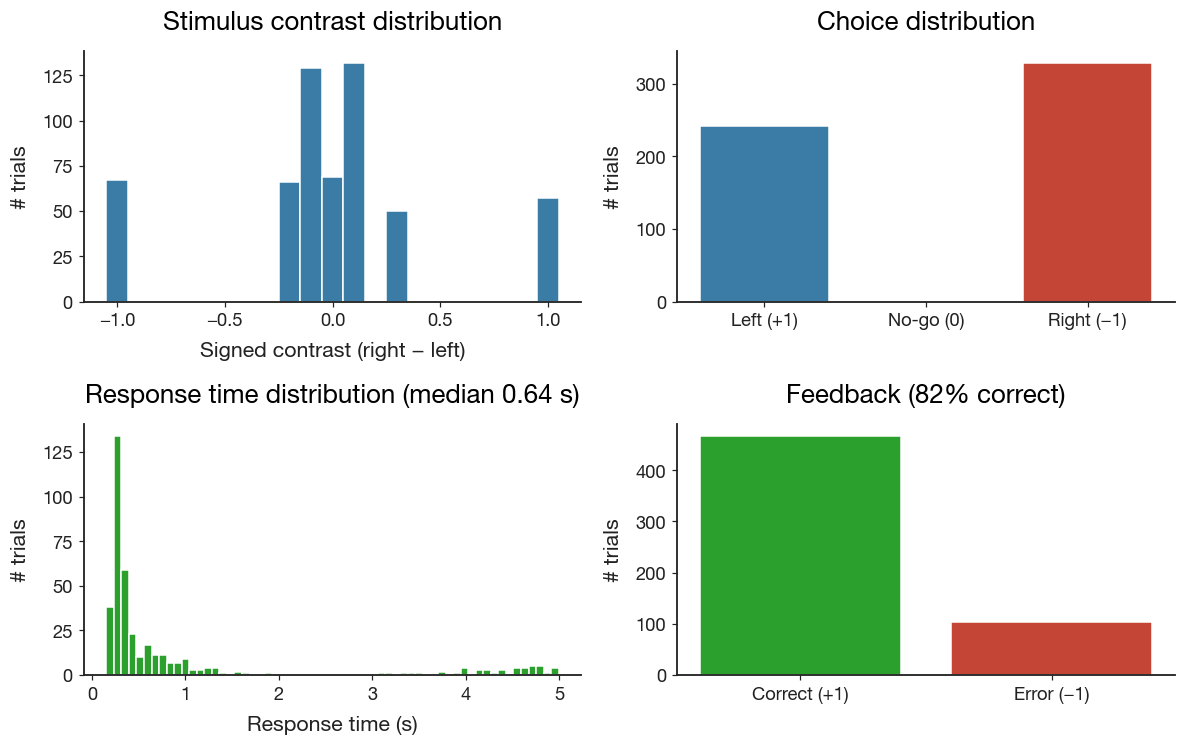

In [15]:
# Task design: contrast distribution, choice, response time, reward
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# (a) signed contrast distribution
signed = trials['contrastRight'].fillna(0) - trials['contrastLeft'].fillna(0)
axes[0, 0].hist(signed, bins=np.linspace(-1.05, 1.05, 22), color='#3a7ca5',
                edgecolor='white')
axes[0, 0].set_xlabel('Signed contrast (right − left)')
axes[0, 0].set_ylabel('# trials'); axes[0, 0].set_title('Stimulus contrast distribution')

# (b) choice distribution
axes[0, 1].bar(['Left (+1)', 'No-go (0)', 'Right (−1)'],
               [(trials['choice'] == 1).sum(), (trials['choice'] == 0).sum(),
                (trials['choice'] == -1).sum()],
               color=['#3a7ca5', '#888', '#c44536'], edgecolor='white')
axes[0, 1].set_ylabel('# trials'); axes[0, 1].set_title('Choice distribution')

# (c) RT distribution (response_times − stimOn_times)
rt = (trials['response_times'] - trials['stimOn_times']).dropna()
axes[1, 0].hist(rt[(rt > 0) & (rt < 5)], bins=60, color='#2ca02c', edgecolor='white')
axes[1, 0].set_xlabel('Response time (s)'); axes[1, 0].set_ylabel('# trials')
axes[1, 0].set_title(f'Response time distribution (median {rt.median():.2f} s)')

# (d) feedback type
axes[1, 1].bar(['Correct (+1)', 'Error (−1)'],
               [(trials['feedbackType'] == 1).sum(), (trials['feedbackType'] == -1).sum()],
               color=['#2ca02c', '#c44536'], edgecolor='white')
axes[1, 1].set_ylabel('# trials'); axes[1, 1].set_title(
    f'Feedback ({(trials["feedbackType"] == 1).mean():.0%} correct)')

plt.tight_layout(); plt.show()

## 5. Trial-averaged neural responses

PSTH around stim onset and first movement, per region. Built from the binned spike matrix and the trial timestamps.

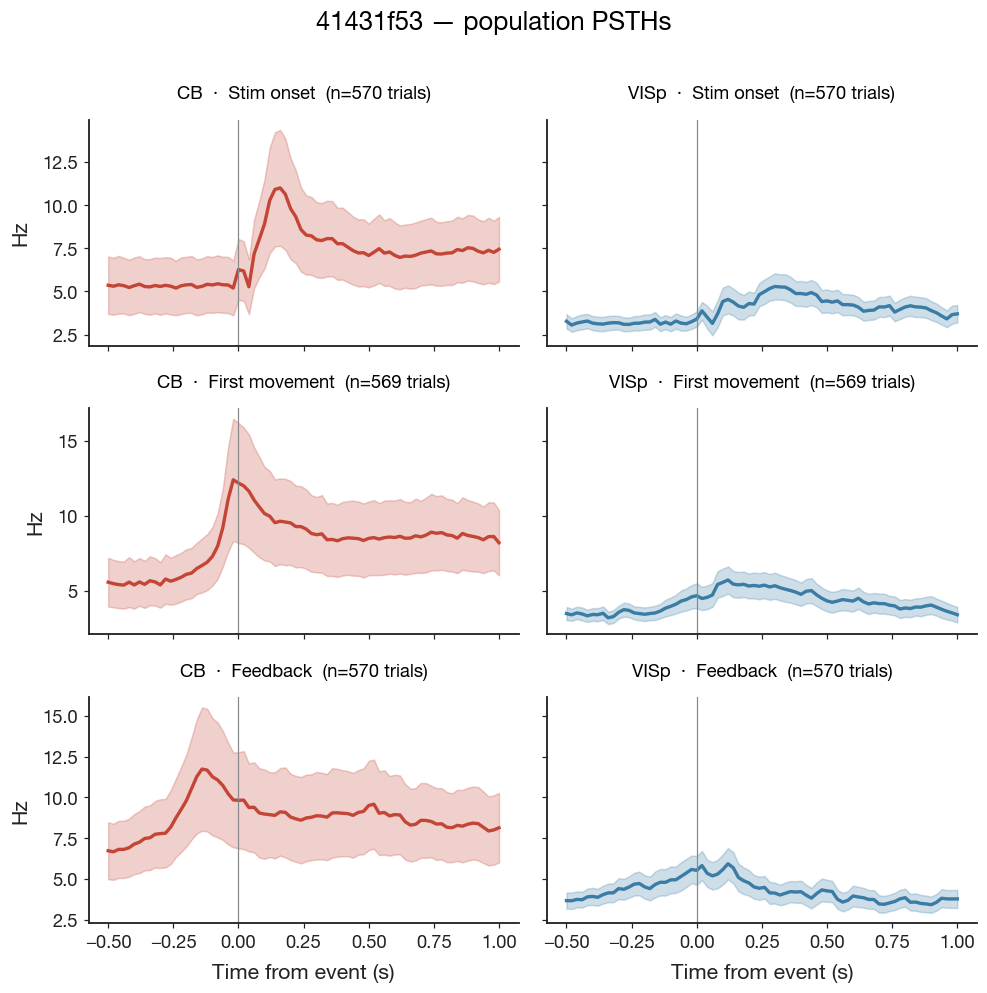

In [16]:
def psth_around(spikes_mat, bin_centers, event_times, window=(-0.5, 1.0), bin_s=0.02):
    """Trial-averaged firing rate around event_times. Returns (n_neurons, n_lags) Hz."""
    lags_s = np.arange(window[0], window[1] + bin_s / 2, bin_s)
    n_neurons = spikes_mat.shape[0]
    out = np.zeros((n_neurons, len(lags_s)))
    n_used = 0
    for t_event in event_times:
        if not np.isfinite(t_event):
            continue
        idx0 = np.searchsorted(bin_centers, t_event + window[0])
        idx1 = idx0 + len(lags_s)
        if idx0 < 0 or idx1 > spikes_mat.shape[1]:
            continue
        out += spikes_mat[:, idx0:idx1]
        n_used += 1
    if n_used:
        out /= n_used
    return out / bin_s, lags_s, n_used  # convert to Hz

events = {
    'Stim onset': trials['stimOn_times'].dropna().to_numpy(),
    'First movement': trials['firstMovement_times'].dropna().to_numpy(),
    'Feedback': trials['feedback_times'].dropna().to_numpy(),
}
fig, axes = plt.subplots(len(events), len(spikes), figsize=(4.6 * len(spikes), 3.0 * len(events)),
                          sharex='col', sharey='row')
if axes.ndim == 1:
    axes = axes[None, :] if len(events) == 1 else axes[:, None]
for r, (label, et) in enumerate(events.items()):
    for c, (roi, mat) in enumerate(spikes.items()):
        psth, lags, n_used = psth_around(mat, bin_centers, et)
        ax = axes[r, c]
        # Plot population mean ± SEM across neurons
        mean = psth.mean(axis=0)
        sem = psth.std(axis=0) / np.sqrt(psth.shape[0])
        ax.fill_between(lags, mean - sem, mean + sem, alpha=0.25,
                        color=_REGION_COLORS.get(roi, '#444'))
        ax.plot(lags, mean, color=_REGION_COLORS.get(roi, '#444'), lw=2.2)
        ax.axvline(0, color='#888', lw=0.8)
        ax.set_title(f'{roi}  ·  {label}  (n={n_used} trials)', fontsize=12)
        if c == 0:
            ax.set_ylabel('Hz')
        if r == len(events) - 1:
            ax.set_xlabel('Time from event (s)')
fig.suptitle(f'{FOCAL_EID[:8]} — population PSTHs', y=1.005)
plt.tight_layout(); plt.show()

## 6. Behavior ↔ neural relationships

How does mean population activity track behavior covariates? Coarse but informative.

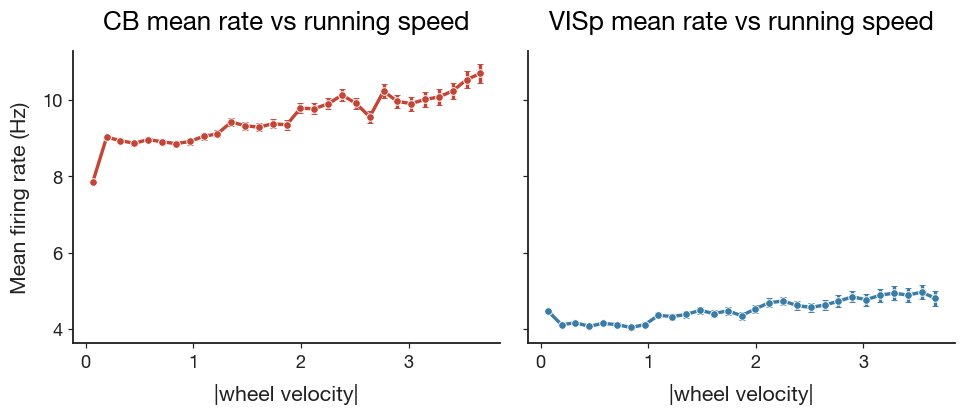

In [17]:
# Pop activity vs running speed (binned-mean scatter)
fig, axes = plt.subplots(1, len(spikes), figsize=(4.5 * len(spikes), 4), sharey=True)
if len(spikes) == 1:
    axes = [axes]
speed = covariates['wheel_velocity'].to_numpy() if 'wheel_velocity' in covariates else None
for ax, (roi, mat) in zip(axes, spikes.items()):
    pop_rate = mat.mean(axis=0) / bin_s
    if speed is None:
        ax.set_visible(False); continue
    bins = np.linspace(np.percentile(np.abs(speed), 1), np.percentile(np.abs(speed), 99), 30)
    abs_speed = np.abs(speed)
    means = []
    sems = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (abs_speed >= lo) & (abs_speed < hi)
        if m.sum() > 50:
            means.append(pop_rate[m].mean()); sems.append(pop_rate[m].std() / np.sqrt(m.sum()))
        else:
            means.append(np.nan); sems.append(np.nan)
    centers_b = 0.5 * (bins[:-1] + bins[1:])
    ax.errorbar(centers_b, means, yerr=sems, color=_REGION_COLORS.get(roi, '#444'),
                lw=2.2, marker='o', ms=5, mec='white', mew=0.6, capsize=2)
    ax.set_xlabel('|wheel velocity|')
    ax.set_title(f'{roi} mean rate vs running speed')
axes[0].set_ylabel('Mean firing rate (Hz)')
plt.tight_layout(); plt.show()

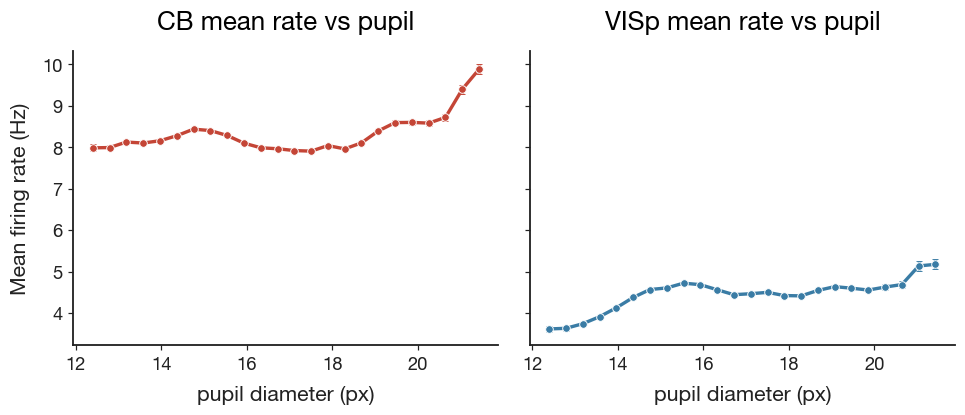

In [18]:
# Pop activity vs pupil diameter
if 'pupil' in covariates.columns:
    fig, axes = plt.subplots(1, len(spikes), figsize=(4.5 * len(spikes), 4), sharey=True)
    if len(spikes) == 1:
        axes = [axes]
    pupil = covariates['pupil'].to_numpy()
    finite = np.isfinite(pupil)
    for ax, (roi, mat) in zip(axes, spikes.items()):
        pop_rate = mat.mean(axis=0) / bin_s
        bins = np.linspace(np.percentile(pupil[finite], 1), np.percentile(pupil[finite], 99), 25)
        means = []; sems = []
        for lo, hi in zip(bins[:-1], bins[1:]):
            m = finite & (pupil >= lo) & (pupil < hi)
            if m.sum() > 50:
                means.append(pop_rate[m].mean()); sems.append(pop_rate[m].std() / np.sqrt(m.sum()))
            else:
                means.append(np.nan); sems.append(np.nan)
        centers_b = 0.5 * (bins[:-1] + bins[1:])
        ax.errorbar(centers_b, means, yerr=sems, color=_REGION_COLORS.get(roi, '#444'),
                    lw=2.2, marker='o', ms=5, mec='white', mew=0.6, capsize=2)
        ax.set_xlabel('pupil diameter (px)')
        ax.set_title(f'{roi} mean rate vs pupil')
    axes[0].set_ylabel('Mean firing rate (Hz)')
    plt.tight_layout(); plt.show()
else:
    print('No pupil covariate cached for this session.')

## 7. Cross-region preview — V1 vs CB top PC time series

The leading principal components of V1 and CB are essentially the inputs to the cross-region CCA. Plotting them together gives an intuitive sense of "do these two regions covary?"

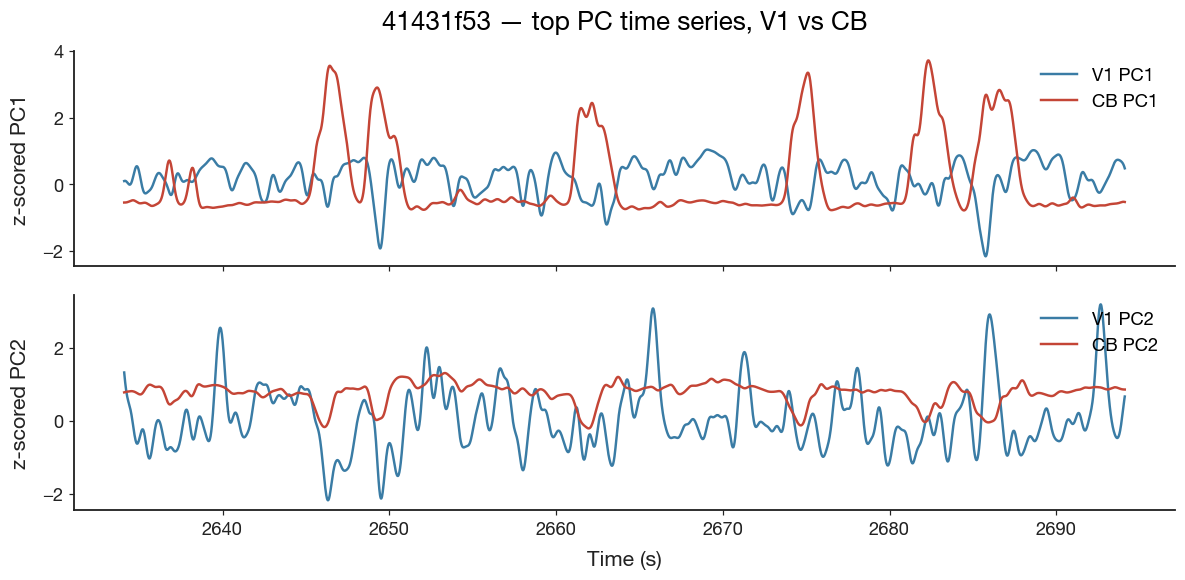

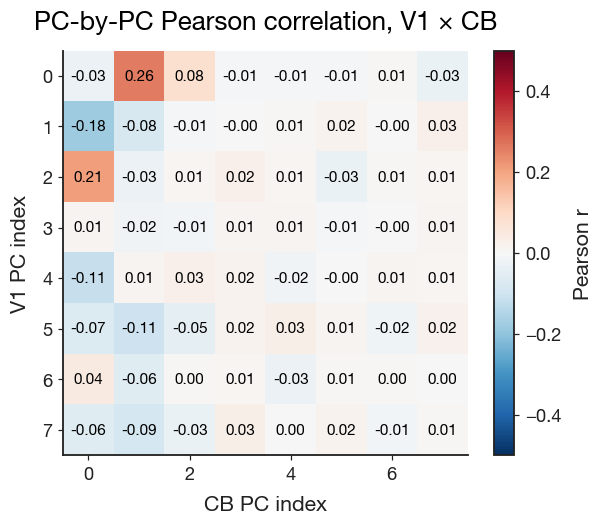

In [19]:
from numpy.linalg import svd as _svd

def top_pc(mat, k=1, smooth_sigma=10):
    Xc = mat.astype(float) - mat.mean(axis=1, keepdims=True)
    _, s, Vt = _svd(Xc, full_matrices=False)
    sc = (s[:k][:, None] * Vt[:k]).T  # (T, k)
    if smooth_sigma:
        sc = gaussian_filter1d(sc, sigma=smooth_sigma, axis=0)
    return sc

if 'VISp' in spikes and 'CB' in spikes:
    sc_v1 = top_pc(spikes['VISp'], k=2)
    sc_cb = top_pc(spikes['CB'], k=2)
    # zscore for visual comparability
    sc_v1 = (sc_v1 - sc_v1.mean(0)) / sc_v1.std(0)
    sc_cb = (sc_cb - sc_cb.mean(0)) / sc_cb.std(0)

    # Plot a 60 s zoom for PC1 of each region
    fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
    axes[0].plot(bin_centers[mask], sc_v1[mask, 0], color=_REGION_COLORS['VISp'], lw=1.6, label='V1 PC1')
    axes[0].plot(bin_centers[mask], sc_cb[mask, 0], color=_REGION_COLORS['CB'], lw=1.6, label='CB PC1')
    axes[0].set_ylabel('z-scored PC1'); axes[0].legend(loc='upper right')
    axes[0].set_title(f'{FOCAL_EID[:8]} — top PC time series, V1 vs CB')

    axes[1].plot(bin_centers[mask], sc_v1[mask, 1], color=_REGION_COLORS['VISp'], lw=1.6, label='V1 PC2')
    axes[1].plot(bin_centers[mask], sc_cb[mask, 1], color=_REGION_COLORS['CB'], lw=1.6, label='CB PC2')
    axes[1].set_ylabel('z-scored PC2'); axes[1].legend(loc='upper right')
    axes[1].set_xlabel('Time (s)')
    plt.tight_layout(); plt.show()

    # Per-component cross-region correlation matrix (for K = 8)
    sc_v1_full = top_pc(spikes['VISp'], k=8, smooth_sigma=0)
    sc_cb_full = top_pc(spikes['CB'], k=8, smooth_sigma=0)
    cc = np.corrcoef(sc_v1_full.T, sc_cb_full.T)[:8, 8:]
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cc, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    for i in range(8):
        for j in range(8):
            ax.text(j, i, f'{cc[i, j]:.2f}', ha='center', va='center', fontsize=10,
                    color='black' if abs(cc[i, j]) < 0.3 else 'white')
    ax.set_xlabel('CB PC index'); ax.set_ylabel('V1 PC index')
    ax.set_title('PC-by-PC Pearson correlation, V1 × CB')
    plt.colorbar(im, ax=ax, fraction=0.046, label='Pearson r')
    plt.tight_layout(); plt.show()
else:
    print('Focal session does not have both VISp and CB cached spike matrices.')

## What to look for in this notebook

- **Section 1.** The cross-region coverage matrix is the bottleneck visualization — diagonal is high, off-diagonal is sparse, simultaneous V1+CB is just 3 sessions.
- **Section 2.** Behavior covariates are heavy-tailed (most bins have wheel velocity ≈ 0; running periods are bursty). Pupil drifts on minute timescales. Wheel velocity and motion energy are correlated but not redundant.
- **Section 3.** CB has the highest median firing rate; V1 has the broadest distribution; CA1 (when present) is sparse. PCA scree shows V1 has more reliable dimensionality than CB on this session.
- **Section 4–5.** Trial structure is the IBL contrast-discrimination task (block prior + signed contrasts + L/R choice). PSTHs show V1 is stim-locked, CB is movement-locked, MO has both.
- **Section 6.** Mean firing rate generally rises with running speed in CB and MO, less so in V1, and ~flat in CA1. Pupil drives a small monotonic effect everywhere.
- **Section 7.** V1 PC1 and CB PC1 *visibly* track each other on the 60 s zoom — the structure CCA picks up. The 8×8 PC-correlation matrix shows the dominant off-diagonal coupling structure.

If anything in here surprises you (e.g. an unexpected PC correlation, a covariate that looks broken, a region with implausibly low firing rates), that's a flag to investigate before trusting the headline result.